In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange


In [2]:
# T = 1.0 
# N = 100000  # Number of samples
# Wi = 1  # Weissenberg number
# kappa = np.array([[1.0, 0.0], [0.0, -1.0]])  # Velocity gradient matrix
# Q0 = np.random.normal(size=(N, D))
# b = 10.0 



### First, we apply a vectorized version of Monte Carlo Simulation without any external libraries.

In [24]:
def F(Q, b):
    norm_Q = np.linalg.norm(Q, axis=1)  # Compute the norm of Q
    return Q / (1 - (norm_Q**2 / b))[:, None] 

def adaptive_euler_maruyama(Q0, kappa, Wi, T, b, delta_t_min):
    N, D = Q0.shape
    Q_traj = [Q0]
    times = [0]
    delta_ts = []  # 添加数组来保存 delta_t 的值
    
    while times[-1] < T:
        Q = Q_traj[-1]
        norm_Q = np.linalg.norm(Q, axis=1)
        
        # Adaptive time step calculation
        term1 = b * Wi * (1/10 * (1 - norm_Q / np.sqrt(b)))**2
        drift_diffusion = np.dot(Q, kappa.T) - (1 / (2 * Wi)) * F(Q, b)
        C_delta_t = 0.001  #?? how to choose this constant????
        term2 = C_delta_t * np.linalg.norm(drift_diffusion, axis=1)**2
        delta_t = np.minimum(term1, term2)
        
        # Ensure delta_t is not smaller than the minimum allowed time step
        delta_t = np.maximum(delta_t, delta_t_min)
        delta_ts.append(delta_t)  # save the minimum delta_t for each step

        
        # Ensure delta_t is reshaped correctly for all operations
        delta_t_reshaped = delta_t.reshape(-1, 1)
        
        # Generate Brownian motion term 
        dW = np.sqrt(delta_t_reshaped / Wi) * np.random.normal(size=(N, D))

        
        # Compute the drift term
        Q_dot = np.dot(Q, kappa.T) - (0.5 / Wi) * F(Q, b)  # Drift term
        

        
        #Update Q based on the adaptive time step
        #Q_next = Q + Q_dot * delta_t + np.sqrt(delta_t / Wi) * dW
        Q_next = Q + Q_dot * delta_t_reshaped + dW  # Ensure all terms are correctly shaped
        
        
        Q_traj.append(Q_next)
        times.append(times[-1] + delta_t.min())  # Update time with the minimum delta_t for synchronization

    #return np.array(Q_traj), np.array(times)

    return np.array(Q_traj), np.array(times), np.array(delta_ts)  # 返回 delta_ts


In [25]:
# Parameters
Q0 = np.random.multivariate_normal([0, 0], [[0.1, 0], [0, 0.1]], 1000)
kappa = np.array([[1.0, 0.0], [0.0, -1.0]])
Wi = 1
T = 1.0
b = 10.0
delta_t_min = 0.001  # Minimum time step
N =10000

In [26]:
np.random.seed(42)
# Run adaptive time-step simulation
#Q_traj, times = adaptive_euler_maruyama(Q0, kappa, Wi, T, b, delta_t_min)
Q_traj, times, delta_ts = adaptive_euler_maruyama(Q0, kappa, Wi, T, b, delta_t_min)

# Calculate the Monte Carlo estimate of the final state
final_states = Q_traj[-1]  # Use the last element as the final state
Y_hat = np.mean(final_states, axis=0) # Take the mean of the final states
print("Monte Carlo Estimator:", Y_hat)

Monte Carlo Estimator: [-0.03900999  0.00014237]


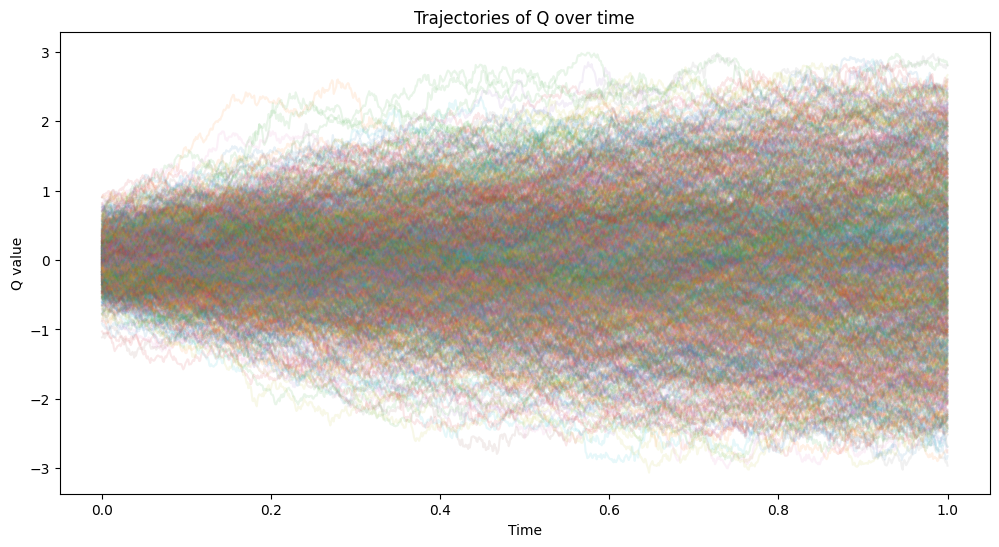

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(min(N, 1000)): 
    plt.plot(times, Q_traj[:, i, 0], alpha=0.1)  # 这里假设你想画出第一个维度的数据

plt.title('Trajectories of Q over time')
plt.xlabel('Time')
plt.ylabel('Q value')
plt.show()


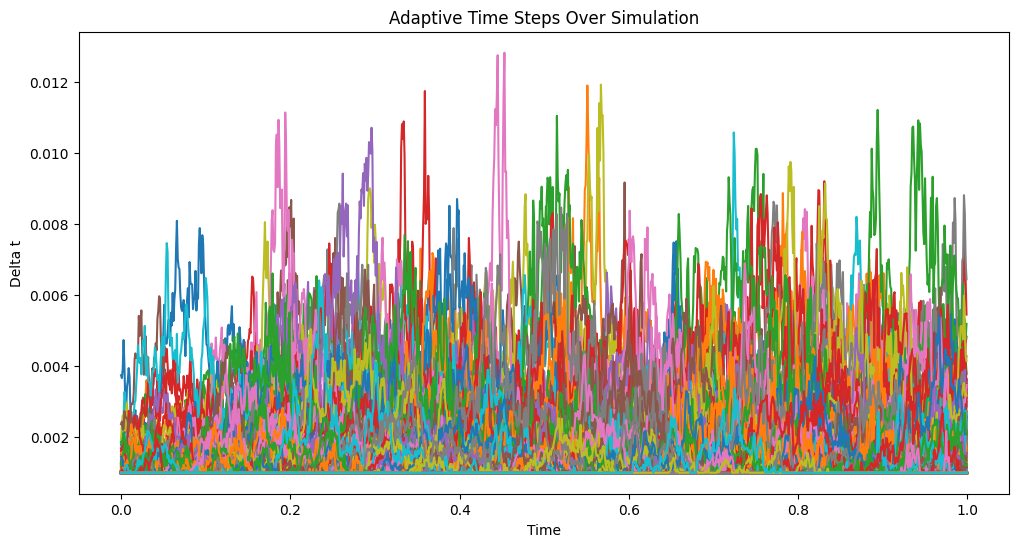

In [29]:
import numpy as np
plt.figure(figsize=(12, 6))
plt.plot(times[:-1], delta_ts, label='Delta t')  # Plot the delta_t values
plt.title('Adaptive Time Steps Over Simulation')
plt.xlabel('Time')
plt.ylabel('Delta t')
#plt.legend()
plt.show()

### As the second step, we apply an alternative version of the vectorized Monte Carlo Simulation using *numba*

In [7]:
from numba import njit
import numpy as np
import numba

@njit
def adaptive_euler_maruyama(Q0, kappa, Wi, T, b, delta_t_min):
    N, D = Q0.shape
    Q_traj = np.empty((0, N, D))  # 修改为使用三维数组保存轨迹
    times = np.zeros(1)  # 初始化时间为零的数组

    while times[-1] < T:
        if len(Q_traj) == 0:
            Q = Q0
        else:
            Q = Q_traj[-1]
        norm_Q = np.sqrt((Q**2).sum(axis=1))  # 直接计算范数

        term1 = b * Wi * (1/10 * (1 - norm_Q / np.sqrt(b)))**2
        drift_diffusion = np.dot(Q, kappa.T) - (1 / (2 * Wi)) * (Q / (1 - (norm_Q**2 / b)))
        C_delta_t = 1
        term2 = C_delta_t * (drift_diffusion**2).sum(axis=1)
        delta_t = np.minimum(term1, term2)

        delta_t_reshaped = delta_t.reshape(-1, 1)

        # 使用 numba 的 random 模块直接生成随机数
        dW = np.sqrt(delta_t_reshaped / Wi) * numba.random.normal(size=(N, D))

        Q_dot = np.dot(Q, kappa.T) - (0.5 / Wi) * (Q / (1 - (norm_Q**2 / b)))
        Q_next = Q + Q_dot * delta_t_reshaped + dW
        
        Q_traj = np.append(Q_traj, [Q_next], axis=0)  # 添加新状态到轨迹
        times = np.append(times, times[-1] + delta_t.min())

    return Q_traj, times

# 其余的参数初始化和模拟运行代码不变


In [8]:
# Parameters
np.random.seed(42)
Q0 = np.random.multivariate_normal([0, 0], [[0.1, 0], [0, 0.1]], 1000)
kappa = np.array([[1.0, 0.0], [0.0, -1.0]])
Wi = 1
T = 1.0
b = 10.0
delta_t_min = 0.001

In [9]:
# Run adaptive time-step simulation
Q_traj, times = adaptive_euler_maruyama(Q0, kappa, Wi, T, b, delta_t_min)


# 计算最终状态的蒙特卡罗估计值
final_states = Q_traj[-1]
Y_hat = np.mean(final_states, axis=0)
print("Monte Carlo Estimator:", Y_hat)

/var/folders/n_/s8ffvqfj3214df41w1r7vzh80000gn/T/ipykernel_5726/1041332461.py:27: NumbaPendingDeprecationWarning: Code using Numba extension API maybe depending on 'old_style' error-capturing, which is deprecated and will be replaced by 'new_style' in a future release. See details at https://numba.readthedocs.io/en/latest/reference/deprecation.html#deprecation-of-old-style-numba-captured-errors
Exception origin:
  File "/Users/luoluoluo/opt/anaconda3/envs/udacity/lib/python3.8/site-packages/numba/core/typing/context.py", line 348, in resolve_module_constants
    attrval = getattr(typ.pymod, attr)

  dW = np.sqrt(delta_t_reshaped / Wi) * numba.random.normal(size=(N, D))


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Internal error at resolving type of attribute "random" of "$240load_global.74".
module 'numba' has no attribute 'random'
During: typing of get attribute at /var/folders/n_/s8ffvqfj3214df41w1r7vzh80000gn/T/ipykernel_5726/1041332461.py (27)
Enable logging at debug level for details.

File "../../../../var/folders/n_/s8ffvqfj3214df41w1r7vzh80000gn/T/ipykernel_5726/1041332461.py", line 27:
<source missing, REPL/exec in use?>
